# **Project Name**    - EDA ON UBER SUPPLY DEMAND GAPS



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 - B SANTOSH KUMAR**


# **GitHub Link -**  https://github.com/bsan5566/labmentix_intern/tree/da63a655f3fe010383c7ac624b8193ac35be7dd8/task2

# **Problem Statement**
The ride-hailing industry, particularly Uber, generates massive amounts of trip request data daily. Understanding patterns in trip requests, cancellations, driver availability, and demand fluctuations is crucial for improving operational efficiency, customer satisfaction, and driver utilization.

However, raw trip request data often contains missing values, inconsistent formats, and lacks meaningful structure for decision-making. Without proper cleaning, analysis, and visualization, it becomes challenging to identify critical issues such as:
- Peak demand hours
- Supply-demand gaps
- High cancellation zones
- Service efficiency issues

## **Objectives**
In this project, the objective is to:

1. **Clean and preprocess** the Uber Request Data to ensure data quality.
2. **Store and manage** the cleaned dataset in MySQL for structured querying.
3. **Perform SQL-based analysis** to extract actionable insights, such as:
   - Peak demand hours
   - Trip completion and cancellation rates
   - Supply-demand mismatch
   - Average trip duration and driver workload
4. **Visualize results** in an **Excel interactive dashboard** to enable business stakeholders to:
   - Monitor performance metrics in real-time
   - Filter insights by pickup point, status, and time
   - Make informed operational decisions

## **Goal**
The ultimate goal is to transform raw Uber request data into a **decision-support tool** that improves:
- Demand forecasting
- Resource allocation
- Overall service quality

#***Data Wrangling***

### Importing libraries


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading


In [3]:
uber_data = pd.read_csv('uber_data.csv')

Dataset first view

In [4]:
uber_data.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset Rows & Columns count

In [5]:
uber_data.shape

(6745, 6)

### Dataset Information

In [6]:
uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


## Handling Multiple Date Formats in Uber Request Data

In [7]:
# Two date formats are found in the date columns
# Handling the two date formats by parsing it seperately
uber_data['Request timestamp1'] = pd.to_datetime(uber_data['Request timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
mask = uber_data['Request timestamp1'].isnull()
uber_data.loc[mask, 'Request timestamp1'] = pd.to_datetime(uber_data[mask]['Request timestamp'], format='%d-%m-%Y %H:%M:%S',
                                             errors='coerce')

uber_data['Drop timestamp1'] = pd.to_datetime(uber_data['Drop timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
mask = uber_data['Drop timestamp1'].isnull()
uber_data.loc[mask, 'Drop timestamp1'] = pd.to_datetime(uber_data[mask]['Drop timestamp'], format='%d-%m-%Y %H:%M:%S',
                                             errors='coerce')

In [8]:
uber_data.head(10)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request timestamp1,Drop timestamp1
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00,2016-07-11 11:51:00,2016-07-11 13:00:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47,2016-07-11 17:57:00,2016-07-11 18:47:00
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58,2016-07-12 09:17:00,2016-07-12 09:58:00
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03,2016-07-12 21:08:00,2016-07-12 22:03:00
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47,2016-07-13 08:33:16,2016-07-13 09:25:47
5,3879,Airport,1.0,Trip Completed,13-07-2016 21:57:28,13-07-2016 22:28:59,2016-07-13 21:57:28,2016-07-13 22:28:59
6,4270,Airport,1.0,Trip Completed,14-07-2016 06:15:32,14-07-2016 07:13:15,2016-07-14 06:15:32,2016-07-14 07:13:15
7,5510,Airport,1.0,Trip Completed,15-07-2016 05:11:52,15-07-2016 06:07:52,2016-07-15 05:11:52,2016-07-15 06:07:52
8,6248,City,1.0,Trip Completed,15-07-2016 17:57:27,15-07-2016 18:50:51,2016-07-15 17:57:27,2016-07-15 18:50:51
9,267,City,2.0,Trip Completed,11/7/2016 6:46,11/7/2016 7:25,2016-07-11 06:46:00,2016-07-11 07:25:00


### Deleting columns

In [9]:
# Deleting unnecessary columns

uber_data= uber_data.drop(['Request timestamp', 'Drop timestamp'], axis =1)

uber_data = uber_data.rename(columns = {'Request timestamp1' : 'Request timestamp'})
uber_data = uber_data.rename(columns = {'Drop timestamp1' : 'Drop timestamp'})

### Normalizing Columns

In [10]:
uber_data['Request timestamp'].value_counts(normalize=True)*100

,proportion
Request timestamp,
2016-07-11 08:37:00,0.088955
2016-07-11 19:02:00,0.088955
2016-07-11 09:40:00,0.088955
2016-07-11 17:57:00,0.088955
2016-07-11 09:24:00,0.074129
...,...
2016-07-15 22:13:11,0.014826
2016-07-14 00:38:22,0.014826
2016-07-14 08:31:12,0.014826


In [11]:
uber_data['Drop timestamp'].value_counts(normalize=True)*100

,proportion
Drop timestamp,
2016-07-12 06:22:00,0.141293
2016-07-12 21:53:00,0.141293
2016-07-12 21:04:00,0.141293
2016-07-11 13:00:00,0.141293
2016-07-11 10:10:00,0.105970
...,...
2016-07-14 06:54:57,0.035323
2016-07-14 05:07:30,0.035323
2016-07-14 01:02:24,0.035323


### Correcting DataTypes

In [12]:
# correcting data types

uber_data['Request timestamp']=pd.to_datetime(uber_data['Request timestamp'])
uber_data['Drop timestamp']=pd.to_datetime(uber_data['Drop timestamp'])

In [13]:
uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [14]:
uber_data.describe()

,Request id,Driver id,Request timestamp,Drop timestamp
count,6745.000000,4095.000000,6745,2831
mean,3384.644922,149.501343,2016-07-13 13:43:04.303039232,2016-07-13 13:15:33.899328768
min,1.000000,1.000000,2016-07-11 00:00:00,2016-07-11 00:51:00
25%,1691.000000,75.000000,2016-07-12 07:51:00,2016-07-12 07:42:00
50%,3387.000000,149.000000,2016-07-13 14:23:37,2016-07-13 12:14:06
75%,5080.000000,224.000000,2016-07-14 19:39:27,2016-07-14 19:13:52
max,6766.000000,300.000000,2016-07-15 23:59:58,2016-07-16 01:09:24
std,1955.099667,86.051994,NaN,NaN


### Unique Values

In [15]:
# Checking if the request ID's are unique

print(len(uber_data['Request id'].unique()))
print(uber_data.shape[0])

6745
6745


In [16]:
# unique values in dataframe for each column

uber_data['Pickup point'].value_counts()

,count
Pickup point,
City,3507
Airport,3238


In [17]:
uber_data['Request id'].value_counts().head()

,count
Request id,
6753,1
619,1
867,1
1807,1
2532,1


In [18]:
uber_data['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [19]:
uber_data['Request timestamp'].value_counts().head()

,count
Request timestamp,
2016-07-11 08:37:00,6
2016-07-11 19:02:00,6
2016-07-11 09:40:00,6
2016-07-11 17:57:00,6
2016-07-11 09:24:00,5


In [20]:
uber_data['Drop timestamp'].value_counts().head()

,count
Drop timestamp,
2016-07-12 06:22:00,4
2016-07-12 21:53:00,4
2016-07-12 21:04:00,4
2016-07-11 13:00:00,4
2016-07-11 10:10:00,3


### Handling Null Values

In [21]:
# Computing number of null values in each column

uber_data.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914


In [22]:
# Inspecting null values in drop  time column
# 3914 null values in the column
uber_data[uber_data['Drop timestamp'].isnull()].groupby('Status').size()

,0
Status,
Cancelled,1264
No Cars Available,2650


In [23]:
uber_data[uber_data['Driver id'].isnull()].groupby('Status').size()

,0
Status,
No Cars Available,2650


In [24]:
# checking existence of duplicate rows
# If sum = 0, there are no duplicate rows

sum(uber_data.duplicated(subset="Request id"))== 0

True

In [25]:
# Categorizing the drop hour and request hour columns
trip_time_label = ["Late night", "Early morning","Late morning", "Afternoon","Evening", "Night"]
bins = [1,4,8,12,16,20,24]

In [26]:
uber_data["Request date"] = uber_data["Request timestamp"].dt.date
uber_data["Request hour"] = uber_data["Request timestamp"].dt.hour
uber_data["Request day"] = uber_data["Request timestamp"].dt.day_name()
uber_data['Request hour timeslot'] = pd.cut(uber_data['Request hour'], bins, labels =trip_time_label)

In [27]:
uber_data["Drop date"] = uber_data["Drop timestamp"].dt.date
uber_data["Drop hour"] = uber_data["Drop timestamp"].dt.hour
uber_data["Drop day"] = uber_data["Drop timestamp"].dt.day_name()
uber_data['Drop hour timeslot'] = pd.cut(uber_data['Drop hour'], bins, labels =trip_time_label)

In [28]:
# Setting Request id as index of the dataframe
uber_data = uber_data.set_index(['Request id'])
uber_data.head()

,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request date,Request hour,Request day,Request hour timeslot,Drop date,Drop hour,Drop day,Drop hour timeslot
Request id,,,,,,,,,,,,,
619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11,11,Monday,Late morning,2016-07-11,13.0,Monday,Afternoon
867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11,17,Monday,Evening,2016-07-11,18.0,Monday,Evening
1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12,9,Tuesday,Late morning,2016-07-12,9.0,Tuesday,Late morning
2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12,21,Tuesday,Night,2016-07-12,22.0,Tuesday,Night
3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13,8,Wednesday,Early morning,2016-07-13,9.0,Wednesday,Late morning


In [29]:
uber_data['Request date'].value_counts(normalize=True)*100

,proportion
Request date,
2016-07-15,20.474426
2016-07-11,20.266864
2016-07-14,20.059303
2016-07-13,19.822090
2016-07-12,19.377317


In [30]:
uber_data['Drop date'].value_counts(normalize=True)*100

,proportion
Drop date,
2016-07-11,20.558107
2016-07-13,20.098905
2016-07-12,20.063582
2016-07-15,19.286471
2016-07-14,18.933239
2016-07-16,1.059696


In [31]:
# Computing trip duration for completed trips

uber_data['Trip duration_min'] = (uber_data['Drop timestamp'] - uber_data['Request timestamp']).dt.total_seconds() / 60
uber_data['Trip duration_hr'] = (uber_data['Drop timestamp'] - uber_data['Request timestamp']).dt.total_seconds() / 3600
uber_data.head()

,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request date,Request hour,Request day,Request hour timeslot,Drop date,Drop hour,Drop day,Drop hour timeslot,Trip duration_min,Trip duration_hr
Request id,,,,,,,,,,,,,,,
619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11,11,Monday,Late morning,2016-07-11,13.0,Monday,Afternoon,69.000000,1.150000
867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11,17,Monday,Evening,2016-07-11,18.0,Monday,Evening,50.000000,0.833333
1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12,9,Tuesday,Late morning,2016-07-12,9.0,Tuesday,Late morning,41.000000,0.683333
2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12,21,Tuesday,Night,2016-07-12,22.0,Tuesday,Night,55.000000,0.916667
3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13,8,Wednesday,Early morning,2016-07-13,9.0,Wednesday,Late morning,52.516667,0.875278


In [32]:
uber_data[uber_data['Status'] == "Cancelled"].head()

,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request date,Request hour,Request day,Request hour timeslot,Drop date,Drop hour,Drop day,Drop hour timeslot,Trip duration_min,Trip duration_hr
Request id,,,,,,,,,,,,,,,
2905,City,1.0,Cancelled,2016-07-13 06:08:41,NaT,2016-07-13,6,Wednesday,Early morning,NaT,NaN,NaN,NaN,NaN,NaN
4805,City,1.0,Cancelled,2016-07-14 17:07:58,NaT,2016-07-14,17,Thursday,Evening,NaT,NaN,NaN,NaN,NaN,NaN
5202,Airport,1.0,Cancelled,2016-07-14 20:51:37,NaT,2016-07-14,20,Thursday,Evening,NaT,NaN,NaN,NaN,NaN,NaN
5927,City,1.0,Cancelled,2016-07-15 10:12:40,NaT,2016-07-15,10,Friday,Late morning,NaT,NaN,NaN,NaN,NaN,NaN
2347,Airport,2.0,Cancelled,2016-07-12 19:14:00,NaT,2016-07-12,19,Tuesday,Evening,NaT,NaN,NaN,NaN,NaN,NaN


In [33]:
# Set the drop columns and trip duration to NaN when status is cancelled and no cars available

uber_data.loc[uber_data['Status'] == "No Cars Available",['Drop date','Drop hour', 'Drop day', 'Drop hour timeslot', 'Trip duration_min', 'Trip duration_hr']] = np.nan
uber_data.loc[uber_data['Status'] == "Cancelled",['Drop date','Drop hour','Drop day', 'Drop hour timeslot', 'Trip duration_min', 'Trip duration_hr']] = np.nan

uber_data[uber_data['Status'] == "Cancelled"].head()

,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request date,Request hour,Request day,Request hour timeslot,Drop date,Drop hour,Drop day,Drop hour timeslot,Trip duration_min,Trip duration_hr
Request id,,,,,,,,,,,,,,,
2905,City,1.0,Cancelled,2016-07-13 06:08:41,NaT,2016-07-13,6,Wednesday,Early morning,NaN,NaN,NaN,NaN,NaN,NaN
4805,City,1.0,Cancelled,2016-07-14 17:07:58,NaT,2016-07-14,17,Thursday,Evening,NaN,NaN,NaN,NaN,NaN,NaN
5202,Airport,1.0,Cancelled,2016-07-14 20:51:37,NaT,2016-07-14,20,Thursday,Evening,NaN,NaN,NaN,NaN,NaN,NaN
5927,City,1.0,Cancelled,2016-07-15 10:12:40,NaT,2016-07-15,10,Friday,Late morning,NaN,NaN,NaN,NaN,NaN,NaN
2347,Airport,2.0,Cancelled,2016-07-12 19:14:00,NaT,2016-07-12,19,Tuesday,Evening,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Find max and min values of trip duration in minutes to bin the values

print("Max: " ,uber_data['Trip duration_min'].max())
print("Min: " ,uber_data['Trip duration_min'].min())

Max:  83.0
Min:  20.783333333333335


In [35]:
# Binning trip duration in minutes, bin for every 15 mins

uber_data['trip duration slot'] = pd.cut(x=uber_data['Trip duration_min'], bins=[1, 15, 30, 45, 60, 75, 90] , labels=['1 to 15', '16 to 30', '31 to 45', '46 to 60', '61 to 75', '75-90'])
uber_data['trip duration slot'].value_counts()

,count
trip duration slot,
46 to 60,944
31 to 45,844
61 to 75,812
16 to 30,126
75-90,105
1 to 15,0


In [36]:
# Checking if the column is binned by comparing the counts

print(uber_data['trip duration slot'].value_counts().sum())
print(uber_data.Status.value_counts())

2831
Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64


In [37]:
# Deleting timestamp columns
uber_data.drop(['Request timestamp', 'Drop timestamp'], axis =1, inplace = True)

## ***Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [38]:
uber_data.head(10)

,Pickup point,Driver id,Status,Request date,Request hour,Request day,Request hour timeslot,Drop date,Drop hour,Drop day,Drop hour timeslot,Trip duration_min,Trip duration_hr,trip duration slot
Request id,,,,,,,,,,,,,,
619,Airport,1.0,Trip Completed,2016-07-11,11,Monday,Late morning,2016-07-11,13.0,Monday,Afternoon,69.000000,1.150000,61 to 75
867,Airport,1.0,Trip Completed,2016-07-11,17,Monday,Evening,2016-07-11,18.0,Monday,Evening,50.000000,0.833333,46 to 60
1807,City,1.0,Trip Completed,2016-07-12,9,Tuesday,Late morning,2016-07-12,9.0,Tuesday,Late morning,41.000000,0.683333,31 to 45
2532,Airport,1.0,Trip Completed,2016-07-12,21,Tuesday,Night,2016-07-12,22.0,Tuesday,Night,55.000000,0.916667,46 to 60
3112,City,1.0,Trip Completed,2016-07-13,8,Wednesday,Early morning,2016-07-13,9.0,Wednesday,Late morning,52.516667,0.875278,46 to 60
3879,Airport,1.0,Trip Completed,2016-07-13,21,Wednesday,Night,2016-07-13,22.0,Wednesday,Night,31.516667,0.525278,31 to 45
4270,Airport,1.0,Trip Completed,2016-07-14,6,Thursday,Early morning,2016-07-14,7.0,Thursday,Early morning,57.716667,0.961944,46 to 60
5510,Airport,1.0,Trip Completed,2016-07-15,5,Friday,Early morning,2016-07-15,6.0,Friday,Early morning,56.000000,0.933333,46 to 60
6248,City,1.0,Trip Completed,2016-07-15,17,Friday,Evening,2016-07-15,18.0,Friday,Evening,53.400000,0.890000,46 to 60


#### Chart - 1  Count of Trips by Status plot

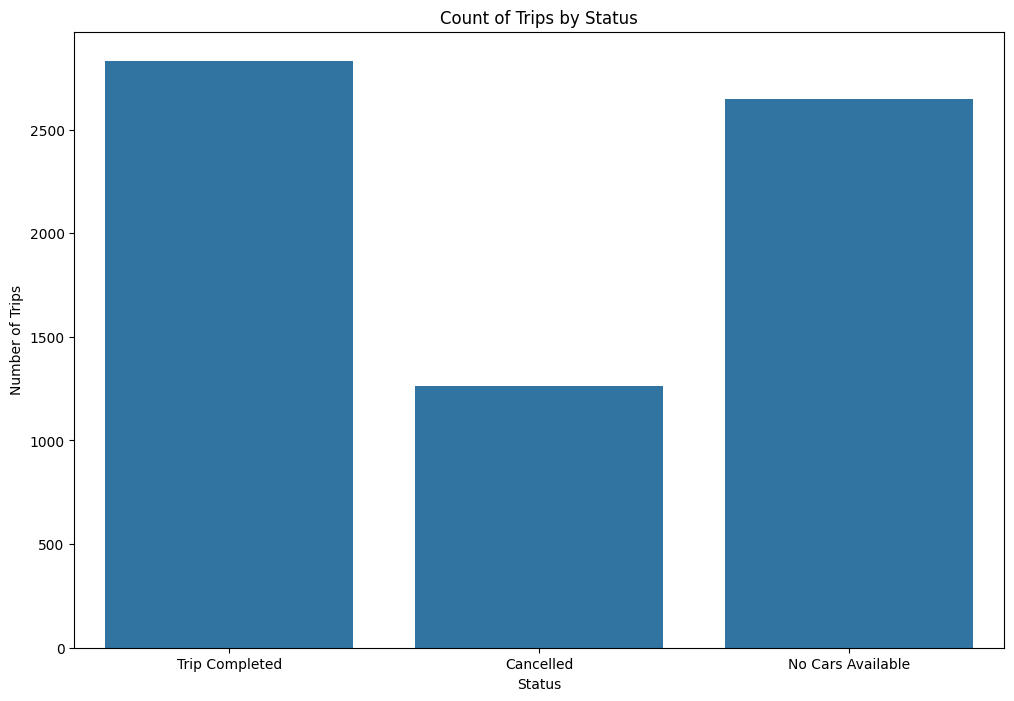

In [39]:
plt.figure(figsize=(12,8))
sns.countplot(x='Status', data=uber_data)
plt.title('Count of Trips by Status')
plt.xlabel('Status')
plt.ylabel('Number of Trips')
plt.show()

#####  What is/are the insight(s) found from the chart?

1. Trip Completed is the highest:
   - The majority of rides were successfully completed, indicating that the system is generally functional and able to fulfill requests.
   - This also suggests that when cars are available, the trips proceed without major operational issues.

2. No Cars Available is the second-highest:
   - A significant number of ride requests could not be fulfilled due to unavailability of cars.
   - This highlights a supply-demand gap, especially during peak hours or in certain locations.
   - Indicates a need for better fleet allocation or driver availability strategies.

3. Cancelled trips are the lowest:
   - Fewer customers canceled trips compared to other issues, which means cancellation is not the major problem.
   - However, cancellations might still be linked to delays in driver assignment or changes in customer plans.

---
*Operational Implications*
- Reducing “No Cars Available” cases could directly increase completed trips and improve revenue.
- The company could investigate time slots or locations with the highest unavailability and take action.


#### Chart - 2- Pickup Point  Insights

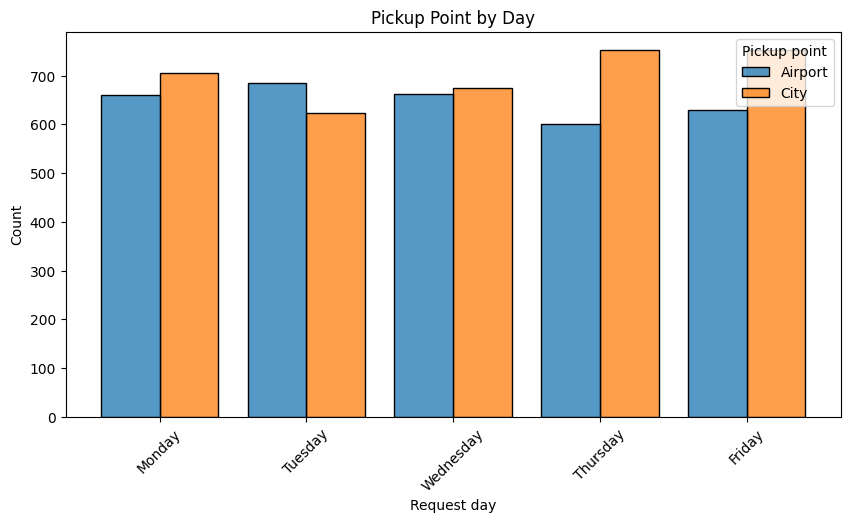

In [40]:
# Pickup Point vs Request Day
plt.figure(figsize=(10,5))
sns.histplot(data=uber_data, x='Request day', hue='Pickup point', multiple='dodge', shrink=0.8)
plt.title("Pickup Point by Day")
plt.xticks(rotation=45)
plt.show()



What is/are the insight(s) found from the chart?

1. City pickups dominate on most days:
   - Except for Tuesday, the City pickup point has slightly more requests than the Airport pickup point.
   - Thursday shows the largest gap, with City pickups significantly higher than Airport pickups.

2. Airport pickups are more stable across the week:
   - Airport requests remain relatively consistent from Monday to Friday, with minor fluctuations.
   - Tuesday has the highest Airport pickup count.

3. City pickups are more variable:
   - City pickups spike on Thursday and Friday, which could be due to increased local travel before weekends.
   - Tuesday has the lowest City pickup count, possibly indicating lower local travel demand mid-week.
---
*Operational Implications*
- If fleet allocation is needed, more cars should be placed in the City on Thursday and Friday to meet demand.
- Airport demand is steady, so allocation can remain consistent across weekdays.

#### Chart - 3 - Number of Pickups per Request Hour

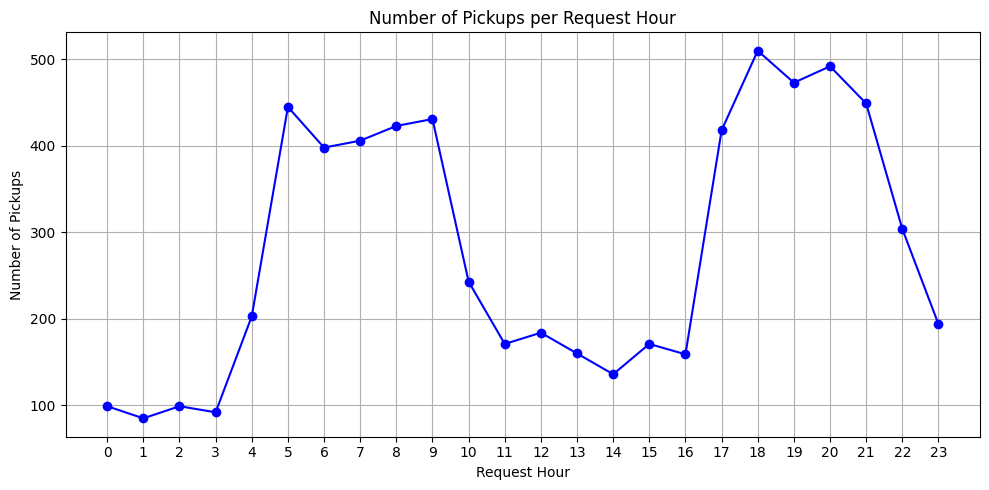

In [41]:
# Count pickups per hour
pickup_counts = uber_data.groupby('Request hour').size()

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(pickup_counts.index, pickup_counts.values, marker='o', linestyle='-', color='blue')

plt.title('Number of Pickups per Request Hour')
plt.xlabel('Request Hour')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))  # Ensure all hours are shown
plt.grid(True)
plt.tight_layout()
plt.show()

What is/are the insight(s) found from the chart?

1. Two major demand peaks

 - Morning peak: Around 5 AM to 9 AM, with the highest demand at 5 AM (~450 pickups). This is likely due to airport drop-offs, office commuters, and early travel needs.

- Evening peak: Around 5 PM to 9 PM, with the highest at 6 PM–8 PM (over 500 pickups). This may be due to office commute returns, evening travel, and leisure trips.

2. Midday dip in demand

 - Between 10 AM and 4 PM, pickups are significantly lower, possibly indicating fewer work commutes and less airport traffic during midday.

 - Lowest activity during midnight to early morning

 - From 12 AM to 3 AM, demand is at its lowest (below 100 pickups), likely due to reduced travel needs at night.
---
*Operational Implications*

- More cars should be allocated between 5 AM–9 AM and 5 PM–9 PM to handle peak demand efficiently.

- Midday and late-night hours require fewer active drivers to optimize operational costs.

#### Chart - 4-  Distribution of Request Day

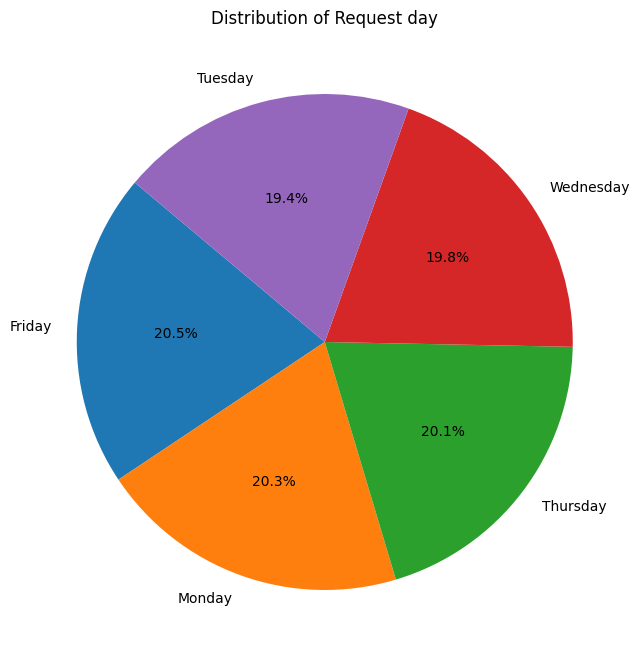

In [42]:
# Pie chart for Status
status_counts = uber_data['Request day'].value_counts()

plt.figure(figsize=(8, 12))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Request day')
plt.show()

What is/are the insight(s) found from the chart?

1. Demand is relatively consistent across weekdays

- All days have request percentages close to 20%, meaning there is no single dominant day for ride requests.

2. Friday has the highest share (20.5%)

* Slightly higher demand compared to other days, possibly due to weekend travel, social outings, or end-of-week commuting.

3. Tuesday has the lowest share (19.4%)

- Slightly lower demand, which might indicate fewer travel needs or commuting patterns early in the week.

---
*Operational Implications*

- Since demand is relatively even, fleet allocation can remain consistent across weekdays.

- Minor adjustments may be made to ensure slightly higher coverage on Fridays.

#### Chart - 5- Distribution of Drop Day

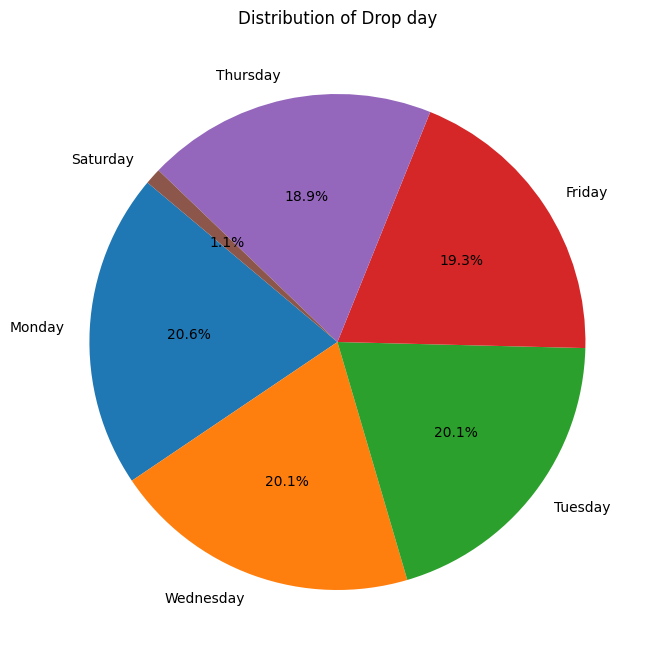

In [43]:
# Pie chart for Status
status_counts = uber_data['Drop day'].value_counts()

plt.figure(figsize=(8, 12))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Drop day')
plt.show()

What is/are the insight(s) found from the chart?

1. Monday has the highest drop rate (20.6%)

- This could be due to overnight or early Monday morning drop-offs from Sunday night travel or weekend returns.

2. Saturday has the lowest drop rate (1.1%)

- Extremely low drop counts on Saturday indicate that very few trips are completed on Saturday, possibly due to fewer requests or more cancellations/no availability.

3. Tuesday to Friday show balanced drop rates (~19–20%)

- Most weekdays have relatively even drop distributions, indicating stable travel behavior during the working week.

4. Thursday drops are lower (18.9%)

- Slightly less than other weekdays, which could reflect fewer trip completions or earlier-week journeys ending midweek.
---
*Operational Implications*
- Focus more on operations from Sunday night to Monday, when drop activity is highest.

- Investigate Saturday to understand why drops are so low — it could reveal issues with driver availability, system downtime, or a low number of trip requests.

- For weekday operations, maintain a uniform strategy since the drop pattern is relatively stable.

#### Chart - 6 -Pickup Requests by Hour

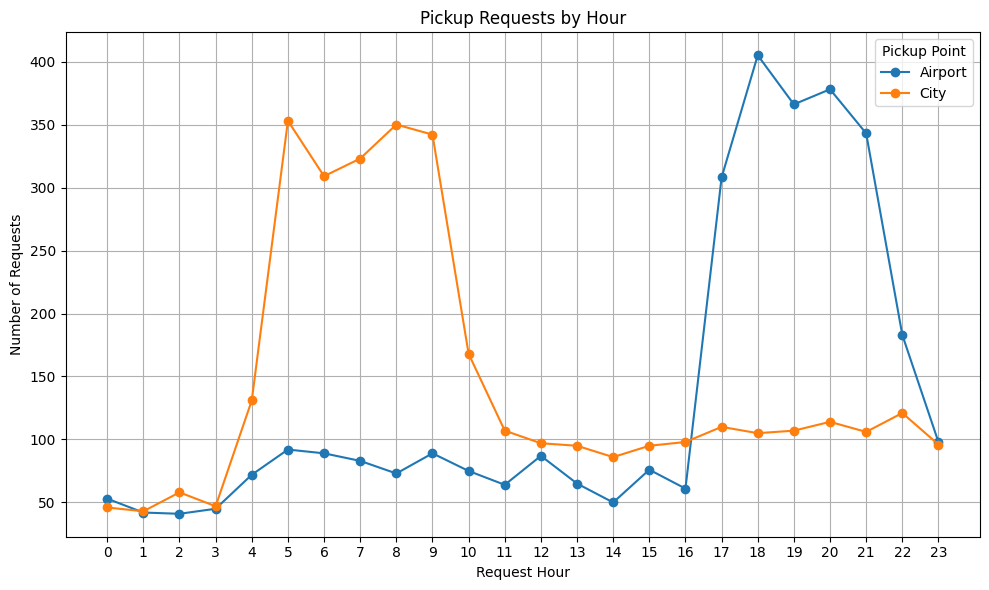

In [44]:
# Group by Request hour and Pickup point
pickup_hourly = uber_data.groupby(['Request hour', 'Pickup point']).size().unstack()

# Plotting
plt.figure(figsize=(10, 6))
for column in pickup_hourly.columns:
    plt.plot(pickup_hourly.index, pickup_hourly[column], marker='o', label=column)

plt.title('Pickup Requests by Hour')
plt.xlabel('Request Hour')
plt.ylabel('Number of Requests')
plt.xticks(range(0, 24))
plt.legend(title='Pickup Point')
plt.grid(True)
plt.tight_layout()
plt.show()

What is/are the insight(s) found from the chart?

1. City pickups dominate in the morning

- Peak city demand occurs between 5 AM and 9 AM, with the highest spike at 5 AM (~350 requests).

- This likely represents office commuters and early morning travel within the city.

2. Airport pickups dominate in the evening

- Peak airport demand occurs between 5 PM and 9 PM, with the highest at 6 PM (~400 requests).

- This suggests evening flight arrivals/departures are a major driver of airport trips.

3. Daytime mid-level demand for city pickups

- Between 10 AM and 4 PM, city requests remain steady but lower than the morning peak (~90–110 requests).

4. Low demand during late night / early morning hours

- Both city and airport pickups are minimal between 12 AM and 3 AM, reflecting reduced travel activity.
---
*Operational Implications*
- Allocate more drivers to the City between 5 AM–9 AM to meet peak morning demand.

- Increase airport driver availability between 5 PM–9 PM to handle evening rush.

- Reduce fleet presence in very late-night hours to optimize operational costs.

- Maintain moderate coverage during midday for city pickups to serve stable but lower demand.

#### Chart - 7 - Distribution of Trip Duration by Pickup Point

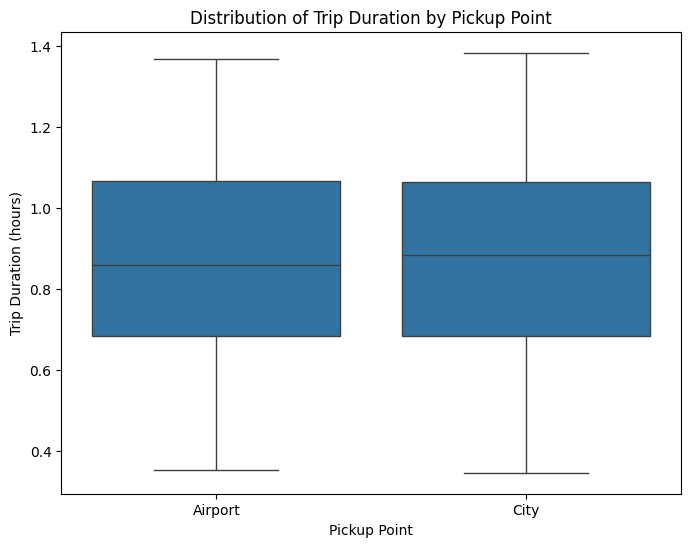

In [45]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pickup point', y='Trip duration_hr', data=uber_data)
plt.title('Distribution of Trip Duration by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Trip Duration (hours)')
plt.show()

What is/are the insight(s) found from the chart?

1. Similar median trip duration for both pickup points

- Airport trips have a median duration of around 0.85 hours, while City trips are slightly higher at about 0.88–0.9 hours.

- This suggests that, on average, trips from both pickup points take a similar amount of time.

2. Similar spread of trip durations

- The interquartile range (middle 50% of data) is similar for both Airport and City pickups, indicating consistent trip time variability for both.

3. Presence of longer trips

- Both pickup points have maximum trip durations close to 1.35–1.38 hours, indicating that outlier long trips occur for both categories.

4. Minimum trip times are similar

- The shortest trips for both Airport and City pickups are around 0.35 hours, suggesting some very short-distance requests.
---
*Operational Implications*
- Since trip durations are consistent across pickup points, fleet scheduling can be planned similarly for both Airport and City trips.

- The presence of long-duration trips should be factored into driver allocation so that drivers are available for new requests after long trips.

- Short trips may indicate last-mile travel needs; optimizing pricing and availability for these could improve customer satisfaction.



#### Chart - 8- Trip Duration Slot by Request Hour (Completed Trips)

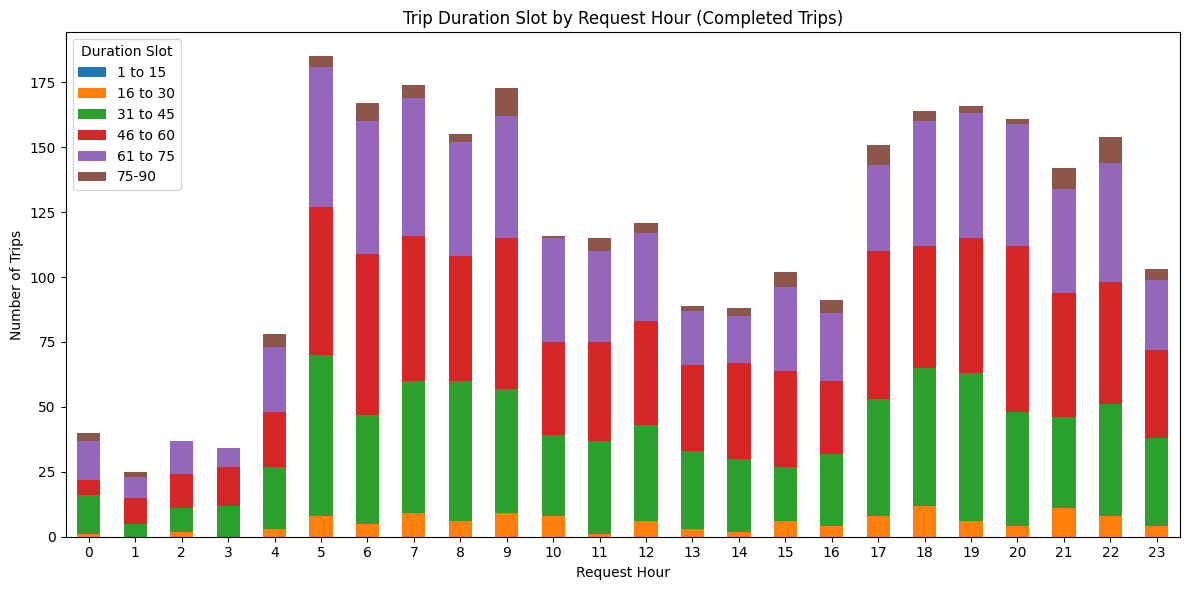

In [46]:
# Filter for completed trips
completed_trips = uber_data[uber_data['Status'] == 'Trip Completed'].copy()

# Pivot table for stacked bar using existing columns
pivot_data = completed_trips.pivot_table(index='Request hour', columns='trip duration slot', aggfunc='size', fill_value=0)

# Simple stacked bar chart
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Trip Duration Slot by Request Hour (Completed Trips)")
plt.xlabel("Request Hour")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.legend(title='Duration Slot')
plt.tight_layout()
plt.show()

What is/are the insight(s) found from the chart?

1. Two main peaks in completed trips

- Morning peak: Around 5 AM to 9 AM, especially high at 5 AM–7 AM, showing many trips starting early in the day.

- Evening peak: Around 5 PM to 9 PM, with significant trip completions, especially at 6 PM–8 PM.

2. Majority of trips last between 31 to 75 minutes

- The 31–45 minutes (green), 46–60 minutes (red), and 61–75 minutes (purple) duration slots dominate across almost all hours.

- Very short trips (1–15 minutes) are rare at all hours.

3. Morning trips tend to be slightly longer

- The 61–75 minute duration range appears more frequently during the morning peak, suggesting longer commutes or airport trips in early hours.

4. Evening trips have a similar spread but slightly more medium durations

- Evening peak trips show a more even distribution between 31–45 minutes and 46–60 minutes, possibly due to shorter return commutes compared to morning outbound trips.

5. Low activity during late night and early morning hours

- Between 12 AM and 4 AM, trip volumes are minimal, and durations are mostly short to medium.
---
*Operational Implications*
- Increase driver availability during 5–9 AM and 5–9 PM to capture the two strong demand peaks.

- Expect longer trips in the morning, so fleet rotation should consider that drivers may take longer to become available again after a trip.

- Since short trips are rare, pricing strategies should focus more on medium-to-long duration rides.

- Reduce driver presence between midnight and 4 AM to save operational costs, as demand is minimal.

#### Chart - 9 Pickup Point vs Status

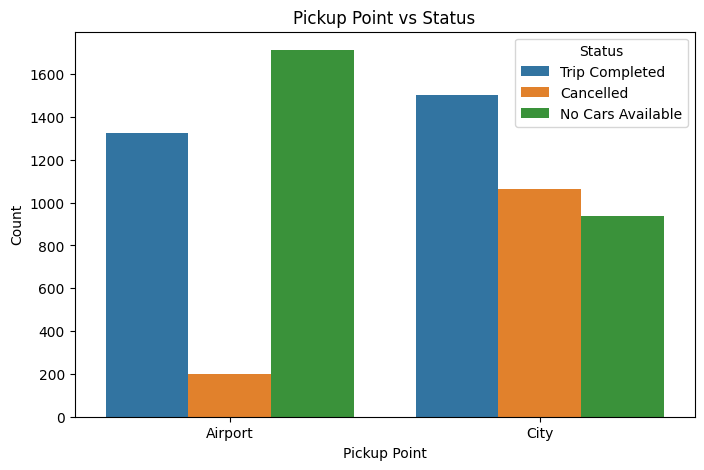

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=uber_data, x='Pickup point', hue='Status')
plt.title("Pickup Point vs Status")
plt.xlabel("Pickup Point")
plt.ylabel("Count")
plt.show()

What is/are the insight(s) found from the chart?

1. Airport pickups face more “No Cars Available” issues

* The highest bar in the chart is No Cars Available at Airport (~1700 trips), indicating a significant supply shortage for airport requests.

2. City pickups have more cancellations

- City requests show more cancellations (~1050 trips) compared to airport requests (~200 trips).

- This may be due to longer wait times, traffic congestion, or customers changing plans in the city.

3. Trip completions are higher in the city

- Completed trips from the city (~1500) are slightly higher than from the airport (~1350).

- This indicates that when vehicles are available, city trips are more likely to be fulfilled.


---
*Operational Implications*
1. For Airport:

- Increase vehicle allocation to reduce “No Cars Available” cases, especially during flight arrival/departure peaks.

- Coordinate with drivers to ensure better coverage during early morning and late-night flight schedules.

2. For City:

- Investigate high cancellation rates — possibly improve estimated arrival times, match customers with nearer drivers, or incentivize drivers to accept rides faster.

- Since trip completion rates are already high when cars are available, focusing on reducing cancellations could directly boost revenue.


#### Chart - 10 -Request Hour vs Request Hour Timeslot

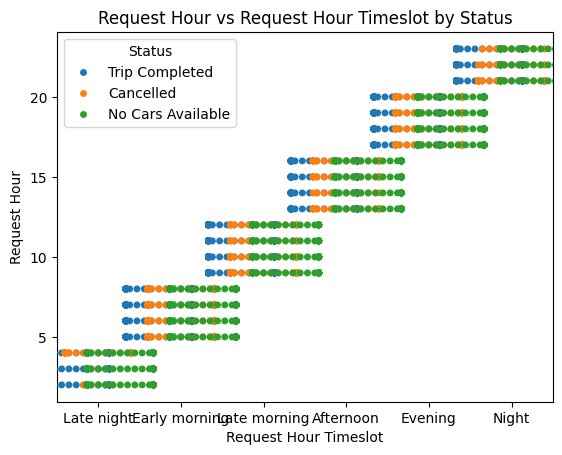

In [48]:
sns.swarmplot(data=uber_data, x='Request hour timeslot', y='Request hour', hue='Status', dodge=True)
plt.title('Request Hour vs Request Hour Timeslot by Status')
plt.xlabel('Request Hour Timeslot')
plt.ylabel('Request Hour')
plt.show()

What is/are the insight(s) found from the chart?

1. Evening and night have the most trip activity

- The dots are most concentrated in Evening (17:00–20:00) and Night (21:00–23:00) timeslots, indicating peak request hours.

2. Early morning also has high request levels

- Another dense cluster appears in the Early Morning (5:00–8:00) timeslot, showing a strong demand surge, likely due to office commutes and early airport departures.

3. Status distribution varies by timeslot

- Evening/Night: Many “No Cars Available” (green) cases, suggesting a supply shortage during late hours.

- Early Morning: Mostly “Trip Completed” (blue) but still noticeable “No Cars Available” cases.

- Afternoon: Lower activity overall, with fewer “No Cars Available” cases.

4. Late night has fewer trips but higher failure rates

- Lower total requests, but a significant proportion are either cancelled (orange) or have no cars available (green).

---
*Operational Implications*
- Boost driver availability in Evening and Night slots to meet high demand and reduce “No Cars Available” cases.

- Maintain good coverage in Early Morning since trip completion rates are high but demand is also significant.

- Consider reducing driver allocation during Afternoon since demand is naturally lower.

#### Chart - 11-Average Trip Duration by Pickup Point and Duration Slot

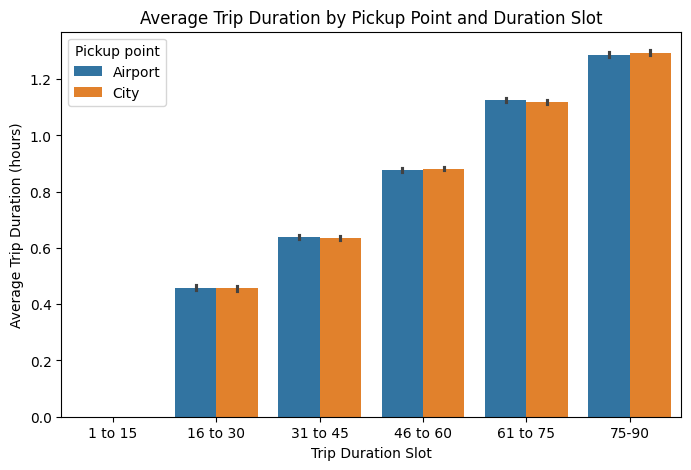

In [49]:
#Bar Plot of Slot an piickup
plt.figure(figsize=(8,5))
sns.barplot(x='trip duration slot', y='Trip duration_hr', hue='Pickup point', data=uber_data)
plt.title("Average Trip Duration by Pickup Point and Duration Slot")
plt.xlabel("Trip Duration Slot")
plt.ylabel("Average Trip Duration (hours)")
plt.show()

What is/are the insight(s) found from the chart?

1. Increasing Trend in Duration:
- As the Trip Duration Slot increases from "1 to 15" to "75-90" minutes, the average trip duration (in hours) consistently increases for both pickup points. This validates that the duration slot classification is consistent and meaningful.

2. Minimal Difference by Pickup Point:

- For each duration slot, the average trip durations for Airport and City pickups are nearly identical. The bars are very close in height, showing no significant difference in average trip times between the two pickup locations.

3. Balanced Service Efficiency:

- Since both pickup points follow similar patterns across all slots, this suggests operational efficiency is fairly consistent regardless of pickup location — useful for fleet management or optimization planning.



4. Low Error Margins:

- The error bars (likely representing standard error or confidence intervals) are very small, suggesting the data is consistent and reliable.

---
*Operational Implications*
- Similar durations from Airport and City — no need for location-specific planning

- Flexible driver allocation between pickup points

- Consistent trip patterns aid in reliable scheduling

- Predictable resource usage (fuel, time, staffing)

- Focus optimization on other factors (e.g., demand, traffic)

- Helps with efficient shift and fleet planning

#### Chart - 12-Hourly Trip Request Distribution by Date"

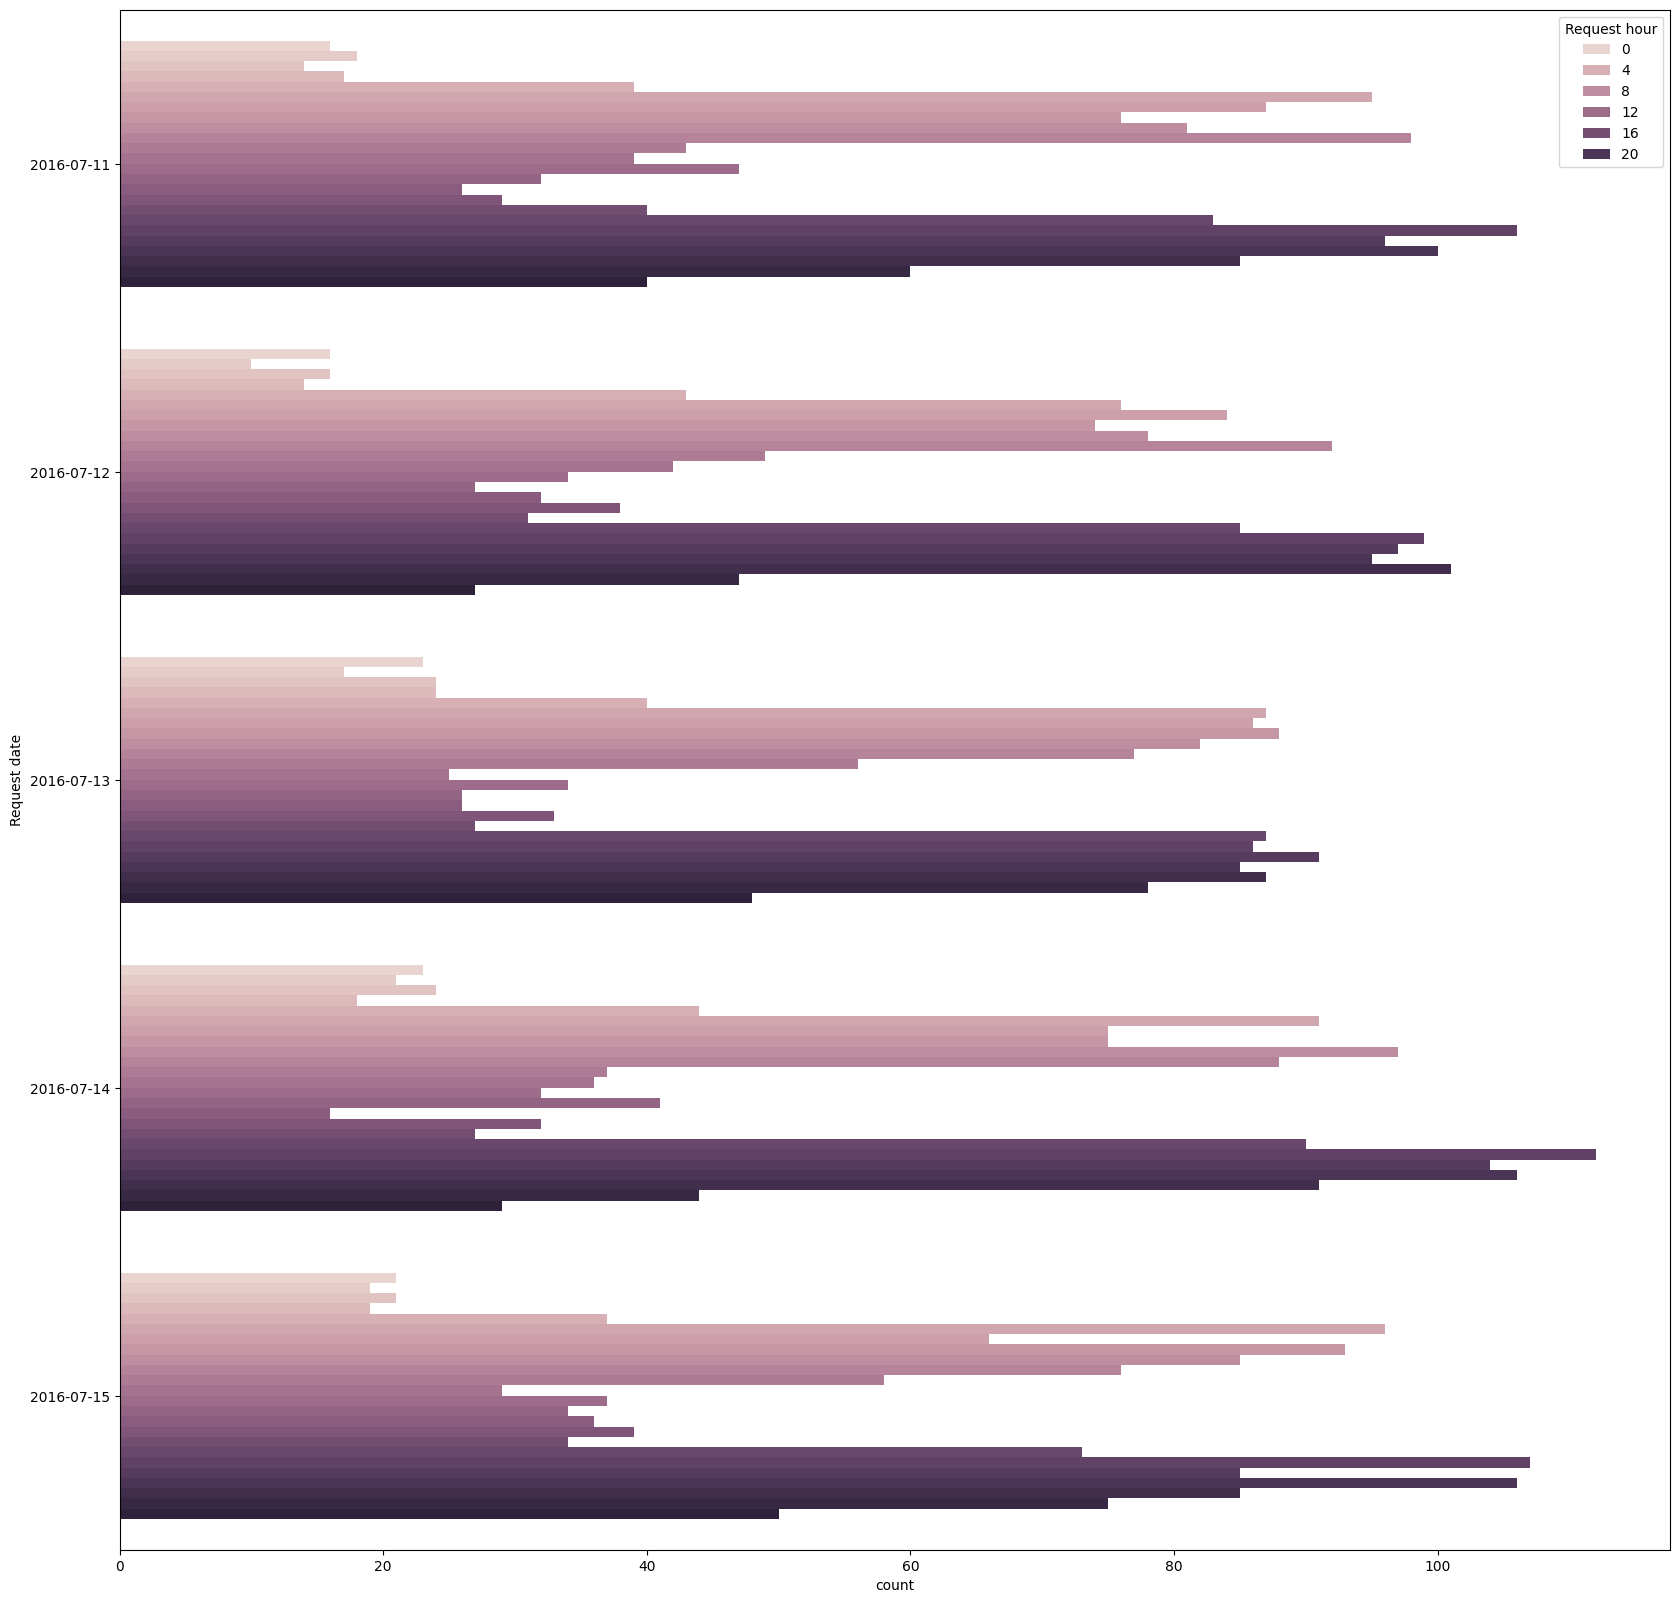

In [50]:
plt.figure(figsize=(20,20))
sns.countplot(data=uber_data, y="Request date", hue="Request hour")
plt.show()

What is/are the insight(s) found from the chart?

1. High Demand Hours:
- Most trip requests are concentrated around hour 20 (8 PM) and hour 16 (4 PM) — consistently across all dates.

- Moderate activity is seen around hour 8 (8 AM) and hour 12 (noon).

- Very few requests occur around midnight to early morning (0–4 hours).

2. Daily Consistency:
- The pattern of requests is similar across the 5 days (July 11 to July 15, 2016), indicating stable customer demand trends.

3. Peak Request Period:
- Across the entire period, the evening peak (around 4 PM–8 PM) remains the highest, suggesting this is a critical window for resource allocation.
---
*Operational Implications*
- Allocate more drivers during 4–8 PM to meet peak demand.

- Early morning hours require minimal resources.

- Maintain consistent staffing for morning and mid-day slots across weekdays.

- Use this pattern for shift scheduling and driver breaks.

#### Chart - 13- Airport & city  Pickups: Trip Status by Request Hour Timeslot

In [51]:
# Splitting the dataframe based on pick up points to do individual analysis

airport = uber_data[uber_data["Pickup point"] == "Airport"]
city = uber_data[uber_data["Pickup point"] == "City"]

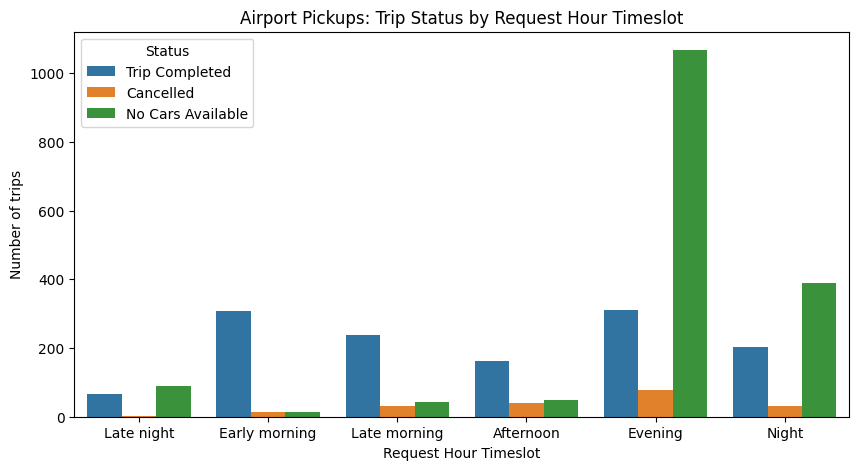

In [52]:
plt.figure(figsize=(10,5))
sns.countplot(data=airport, x="Request hour timeslot", hue="Status")
plt.title("Airport Pickups: Trip Status by Request Hour Timeslot")
plt.xlabel("Request Hour Timeslot")
plt.ylabel("Number of trips")
plt.show()

What is/are the insight(s) found from the chart?

1. Severe Car Shortage in the Evening:

- The "No Cars Available" status peaks dramatically in the Evening, exceeding 1000 requests — the highest of any timeslot or status.

- This indicates a critical supply-demand mismatch during the evening.

2. Most Trips Completed in Early Morning & Evening:

- Trip completions are highest during Early Morning and Evening, indicating these are high-demand periods with good fulfillment (except for car shortages in the evening).

3. Late Night & Night Shortages:

- Late night and night slots show moderate levels of "No Cars Available", suggesting that fleet availability drops significantly during these times.

4. Cancellation is Consistent but Low:

- The number of cancelled trips is relatively low across all timeslots, but slightly higher in the evening, likely due to long wait times or user dissatisfaction.
---
*Operational Implications*
1. Boost car availability in the Evening to reduce lost demand.

2. Increase fleet size or shift drivers to evening slots.

3. Late night and night require moderate attention to car availability.

4. Maintain early morning staffing, which has high trip completion.

5. Monitor cancellations to detect service quality issues.



#### Chart - 14-Trip Duration Trends by Hourly Timeslot of airport

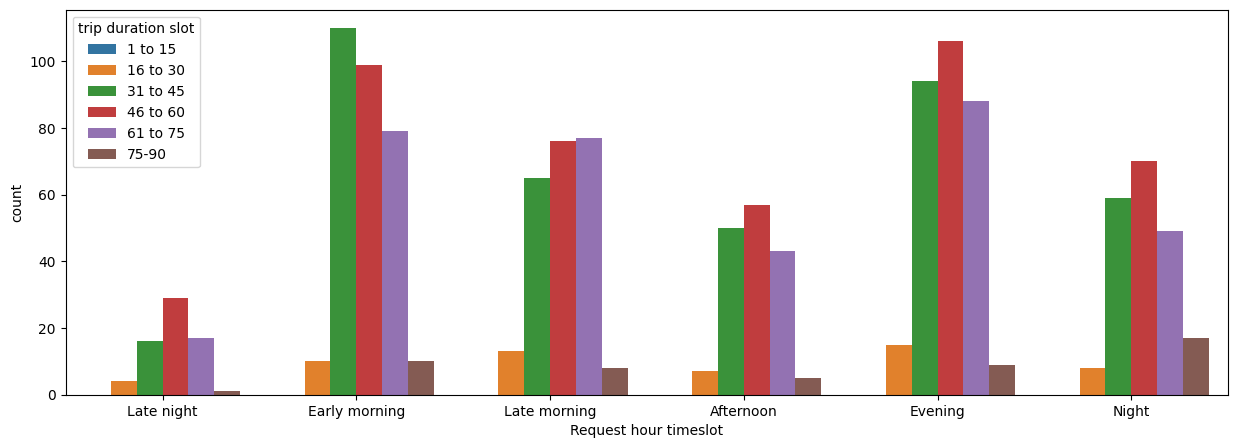

In [53]:
plt.figure(figsize=(15,5))
sns.countplot(data=airport, hue="trip duration slot", x="Request hour timeslot")
plt.show()

What is/are the insight(s) found from the chart?

1. Longer Trips (31–75 mins) Dominate Most Timeslots:

* Across all timeslots, trips of 31–45, 46–60, and 61–75 minutes are the most frequent.

* Especially in early morning, evening, and late morning, these longer durations dominate.

2. Evening and Early Morning See Highest Volume:

- Evening and early morning timeslots show the highest total trip counts, particularly for trips in the 46–60 min and 31–45 min range.

- Indicates high user demand during commute hours.

3. Very Short Trips (1–15 mins) Are Minimal:

- Negligible counts for 1–15 min trips across all timeslots — possibly due to minimum fare thresholds or filtering outliers.

4. Long-Duration Trips (75–90 mins) Are Least Common:

- These are consistently the least frequent, but slightly increase during night and early morning, likely due to long-distance airport runs or intercity travel.
---
*Operational Implications*
- Prioritize mid-to-long trip handling (30–75 mins) during scheduling.

- Evening and early morning demand more drivers and larger fleet availability.

- Monitor 75–90 min trips at night for possible pricing or routing optimizations.

- Minimal short trips — adjust minimum fare strategy accordingly.

- Use these trends to optimize shift timing and route planning.

#### Chart - 15 Trip Duration Slot Counts by Time of Day in city

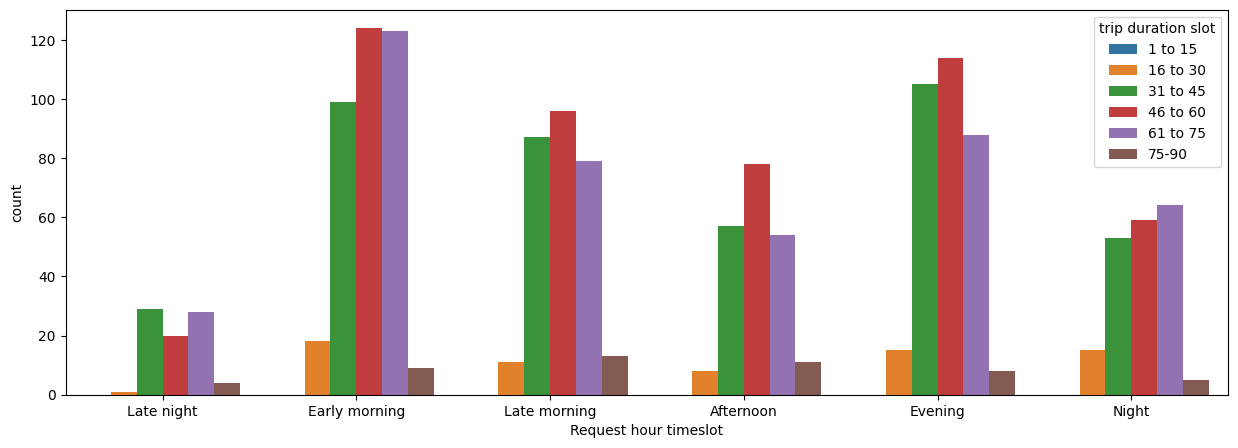

In [54]:
plt.figure(figsize=(15,5))
sns.countplot(data=city, hue="trip duration slot", x="Request hour timeslot")
plt.show()

What is/are the insight(s) found from the chart?

1. Peak Activity in Early Morning:

- The early morning slot has the highest number of trips, especially in the 46–60 and 61–75 minute duration slots.

- Suggests strong early demand, possibly due to airport runs or commute starts.

2. Evening and Late Morning Also High:

- Evening and late morning also show high trip volumes, especially for 31–60 minute durations.

- Reflects return commutes and daily travel peaks.

3. Longer Trips (31–75 mins) Dominate Overall:

- Most trips fall in 31 to 75 minute slots across all time periods, indicating a trend toward medium to long-duration travel.

4. Minimal Very Short Trips (1–15 mins):

- Trips in the 1–15 minute range are nearly nonexistent, possibly filtered out, uncommon, or not cost-effective.

5. Late Night Has Lowest Volume:

- Late night shows the lowest overall trip counts, confirming it as a low-demand period.
---
*Operational Implications*
- Prioritize resources for early morning and evening slots.

- Allocate fleet for medium-long trip handling.

- Deprioritize very short trips and late-night availability unless demand shifts.

- Consider dynamic pricing or driver incentives during peak hours.

# ***Supply Demand Analysis***

In [55]:
# Overall demand through the day at different timeslots at the city

city_demand_supply = pd.DataFrame(city['Request hour timeslot'].value_counts())
city_demand_supply = city_demand_supply.rename(columns = {'count' : 'Demand'})

trips_completed = city[city['Status'] == 'Trip Completed']
city_demand_supply['Supply'] = pd.DataFrame(trips_completed.groupby('Request hour timeslot')['Status'].count())

city_demand_supply['Gap'] = city_demand_supply['Demand'] -city_demand_supply['Supply']
city_demand_supply

,Demand,Supply,Gap
Request hour timeslot,,,
Early morning,1335,373,962
Late morning,714,286,428
Evening,436,330,106
Afternoon,374,208,166
Night,323,196,127
Late night,236,82,154


#### Chart - 16 - Supply demand gap in city

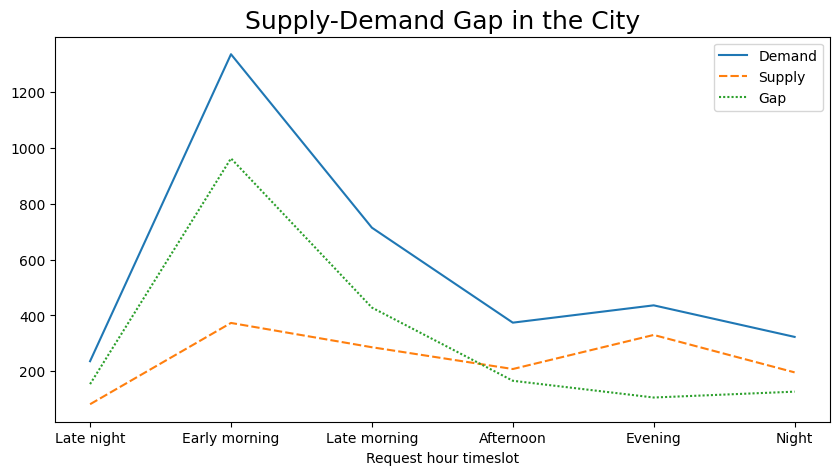

In [56]:
plt.figure(figsize=(10,5))
sns.lineplot(data=city_demand_supply)
plt.title("Supply-Demand Gap in the City", fontsize = 18)
plt.show()

What is/are the insight(s) found from the chart?

1. Severe Gap in Early Morning:

- Demand peaks in early morning (~1350) while supply is much lower (~370).

- The largest gap (~980) occurs in this timeslot, signaling a major mismatch.

2. Consistently Higher Demand Than Supply:

- In every timeslot, demand is greater than supply, showing a system-wide shortage.

3. Late Morning and Afternoon Show Reduced Gap:

- Both demand and supply drop, and so does the gap — indicating a relatively better balance.

4. Evening Shows Recovery in Supply:

- A slight rise in supply during evening hours helps narrow the gap, but demand is still unmet.

5. Late Night and Night Have Smallest Gaps:

- Due to low overall demand, these periods exhibit minimal gaps, suggesting lower urgency for intervention.

---
*Operational Implications*
- Urgent need to increase supply in early morning.

- Consider driver shift realignment or incentives for high-gap times.

- Monitor afternoon and night slots where demand-supply is more balanced.

- Use this gap data to dynamically allocate fleet and improve service reliability.

In [57]:
# Overall Demand, Supply, and Gap by Hour in the City
city_demand_supply = pd.DataFrame(city['Request hour'].value_counts())
city_demand_supply = city_demand_supply.rename(columns = {'count' : 'Demand'})

trips_completed = city[city['Status'] == 'Trip Completed']
city_demand_supply['Supply'] = pd.DataFrame(trips_completed.groupby('Request hour')['Status'].count())

city_demand_supply['Gap'] = city_demand_supply['Demand'] -city_demand_supply['Supply']
city_demand_supply.head(10)

,Demand,Supply,Gap
Request hour,,,
5,353,100,253
8,350,88,262
9,342,99,243
7,323,99,224
6,309,86,223
10,168,63,105
4,131,42,89
22,121,74,47
20,114,87,27


#### Chart - 17 Supply-Demand Gap in the City By Hour

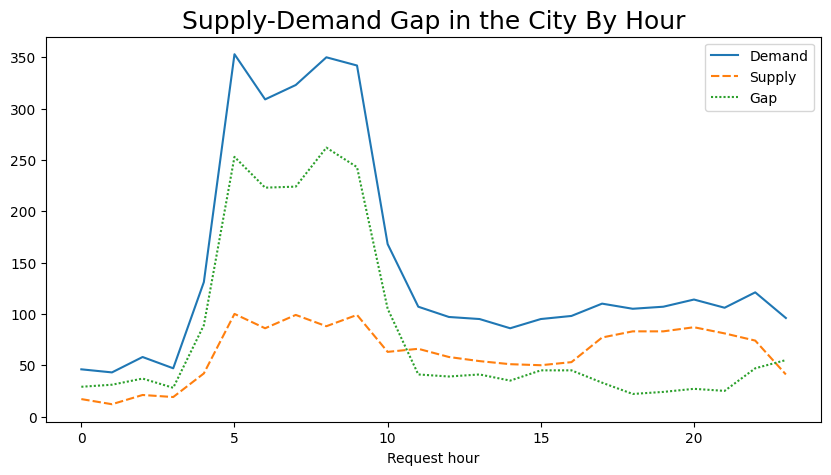

In [58]:
plt.figure(figsize=(10,5))
sns.lineplot(data=city_demand_supply)
plt.title("Supply-Demand Gap in the City By Hour", fontsize = 18)
plt.show()

What is/are the insight(s) found from the chart?

1. Severe Morning Peak (5 AM – 9 AM):

- Demand spikes sharply between 5 AM and 9 AM, peaking around 6–7 AM.

- Gap is widest during this period, indicating critical undersupply.

2. Steady Decline After 9 AM:

- Both demand and supply drop after 9 AM, but the gap narrows, suggesting partial recovery.

3. Evening Stabilization (17:00–22:00):

- In the evening hours, demand and supply are more balanced, with moderate gap levels.

- Indicates better alignment or scheduling during this time.

4. Lowest Activity at Night (0–4 AM):

- Demand and supply are both minimal, with a small gap, likely due to low user activity.
---
*Operational Implications*
- Increase driver availability during 5–9 AM to reduce unmet demand.

- Optimize afternoon scheduling — supply is steady but demand stays low.

- Evening performance is relatively good, can serve as a model for other hours.

- Low activity hours (midnight–4 AM) may not need additional resources.

- Use hourly trends for real-time fleet deployment and shift planning.

In [59]:
# Overall demand through the day at different timeslots at the airport

airport_demand_supply = pd.DataFrame(airport['Request hour timeslot'].value_counts())
airport_demand_supply = airport_demand_supply.rename(columns = {'count' : 'Demand'})

trips_completed = airport[airport['Status'] == 'Trip Completed']
airport_demand_supply['Supply'] = pd.DataFrame(trips_completed.groupby('Request hour timeslot')['Status'].count())

airport_demand_supply['Gap'] = airport_demand_supply['Demand'] -airport_demand_supply['Supply']
airport_demand_supply

,Demand,Supply,Gap
Request hour timeslot,,,
Evening,1457,312,1145
Night,624,203,421
Early morning,337,308,29
Late morning,315,239,76
Afternoon,252,162,90
Late night,158,67,91


#### Chart - 18  Supply demand gap from airport

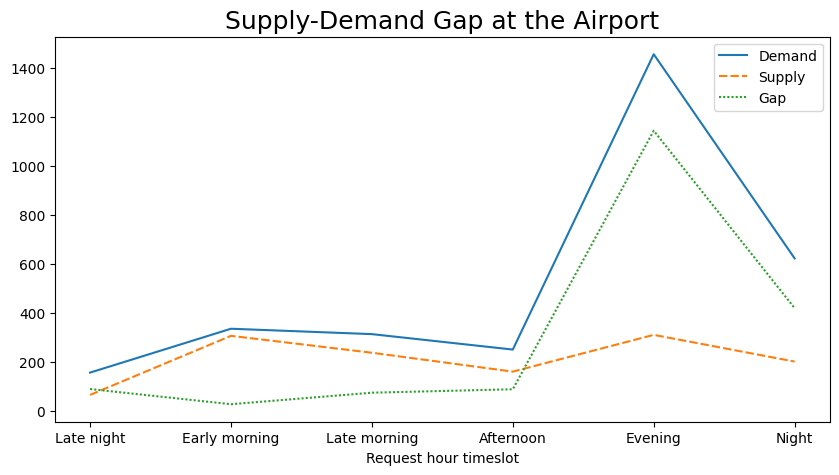

In [60]:
plt.figure(figsize=(10,5))
sns.lineplot(data=airport_demand_supply)
plt.title("Supply-Demand Gap at the Airport", fontsize = 18)
plt.show()

What is/are the insight(s) found from the chart?

1. Massive Evening Demand Surge:

- Evening shows a very sharp rise in demand (~1450 trips) compared to other slots.

- Supply increases only slightly, resulting in a huge gap (~1100 trips) — the most critical imbalance.

2. Low Gap in Early Morning:

- Despite moderate demand, supply nearly matches demand in the early morning, resulting in a minimal gap — indicating good operational alignment.

3. Gap Grows Toward Evening:

- From late morning to evening, demand increases while supply remains relatively flat or dips, leading to a progressive widening of the gap.

4. Late Night and Night Gaps Moderate:

- Demand and supply are both lower during late night and night, keeping the gap smaller compared to peak times.
---
*Operational Implications*
- Urgent fleet reinforcement needed in the evening to address high unmet demand.

- Maintain current early morning strategy — it’s well-balanced.

- Consider dynamic pricing or driver incentives for evening slots.

- Monitor late morning and afternoon for growing gaps.

- Use this data to reallocate airport-bound fleet during peak hours.

In [61]:
# Overall demand through the day at different hours at the airport

airport_demand_supply = pd.DataFrame(airport['Request hour'].value_counts())
airport_demand_supply = airport_demand_supply.rename(columns = {'count' : 'Demand'})
trips_completed = airport[airport['Status'] == 'Trip Completed']
airport_demand_supply['Supply'] = pd.DataFrame(trips_completed.groupby('Request hour')['Status'].count())

airport_demand_supply['Gap'] = airport_demand_supply['Demand'] -airport_demand_supply['Supply']
airport_demand_supply.head(10)

,Demand,Supply,Gap
Request hour,,,
18,405,81,324
20,378,74,304
19,366,83,283
21,343,61,282
17,308,74,234
22,183,80,103
23,98,62,36
5,92,85,7
9,89,74,15


#### Chart - 19- Supply-Demand Gap at the Airport by hour

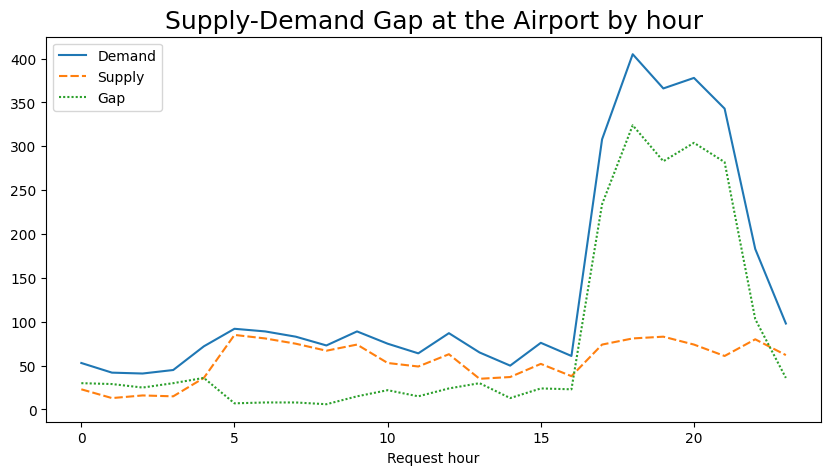

In [62]:
plt.figure(figsize=(10,5))
sns.lineplot(data=airport_demand_supply)
plt.title("Supply-Demand Gap at the Airport by hour", fontsize = 18)
plt.show()

What is/are the insight(s) found from the chart?

1. Sharp Evening Demand Spike (17:00–21:00):

- Demand rises sharply after 16:00, peaking around 18:00–19:00.

- This causes the largest supply-demand gap, reaching over 300 unserved requests.

2. Stable Demand and Supply Until Afternoon:

- From 00:00 to 16:00, both demand and supply remain relatively steady with a small and manageable gap.

- Indicates sufficient fleet coverage during these hours.

3. Moderate Recovery After Peak:

- After 21:00, demand decreases but still stays above supply, though the gap narrows gradually.

4. Early Hours (0–4 AM) Have Low Activity:

- Both supply and demand are low and close, suggesting no major imbalance during the night
---
*Operational Implications*
- Increase fleet allocation from 17:00 to 21:00 to handle peak evening demand at the airport.

- Maintain existing early and mid-day operations — they’re well-balanced.

- Use the trend to restructure driver shifts, ensuring availability during critical hours.

- Dynamic surge pricing or driver incentives in the evening could help reduce unserved requests.

In [63]:
# Demand supply and gap at the airport

airport_demand_supply.apply(lambda x: x.sum())

,0
Demand,3238
Supply,1327
Gap,1911


In [64]:
# Demand supply and gap at the city

city_demand_supply.apply(lambda x: x.sum())

,0
Demand,3507
Supply,1504
Gap,2003


#### Chart - 20 Cor-relation matrix

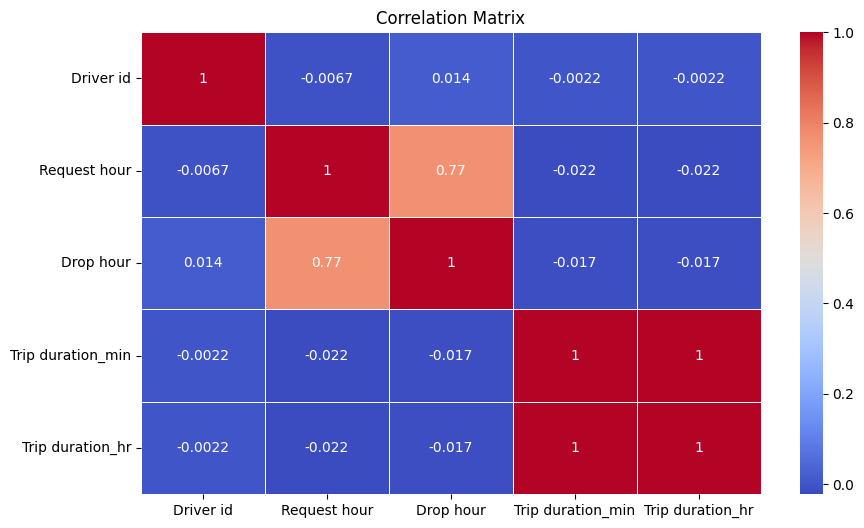

In [ ]:
df_selected = uber_data.select_dtypes(include='number')

# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df_selected.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

What is/are the insight(s) found from the chart?

1. High Correlation between Request Hour and Drop Hour (0.77)

- Suggests that trips tend to start and end within the same hour window.

- Indicates typical short-duration trips.

2. Perfect Correlation between Trip Duration in Minutes and Hours (1.0)

- This is expected since one is a direct conversion of the other (1 hour = 60 minutes).

- Only one of these features is needed in modeling to avoid redundancy (multicollinearity).

3. Low/Negligible Correlations with Driver ID

- Driver ID has almost zero correlation with time or trip duration variables.

- Driver assignment does not influence time or duration of trips significantly.

4. Trip Duration (min/hr) Has Negligible Correlation with Time Variables

- Trip length doesn't vary significantly based on the request or drop hour.
---
*Operational Implications*
- Driver Dispatch: Prioritize location and availability over time; duration is time-independent.

- Feature Selection: Keep only one of Trip duration_min or Trip duration_hr; treat Driver ID as categorical.

- Demand Forecasting: Use high Request hour ↔ Drop hour correlation to identify peak times and optimize schedules.

- Data Efficiency: Drop duplicate time features to reduce storage and simplify processing.



#### Chart - 21 Pairplot

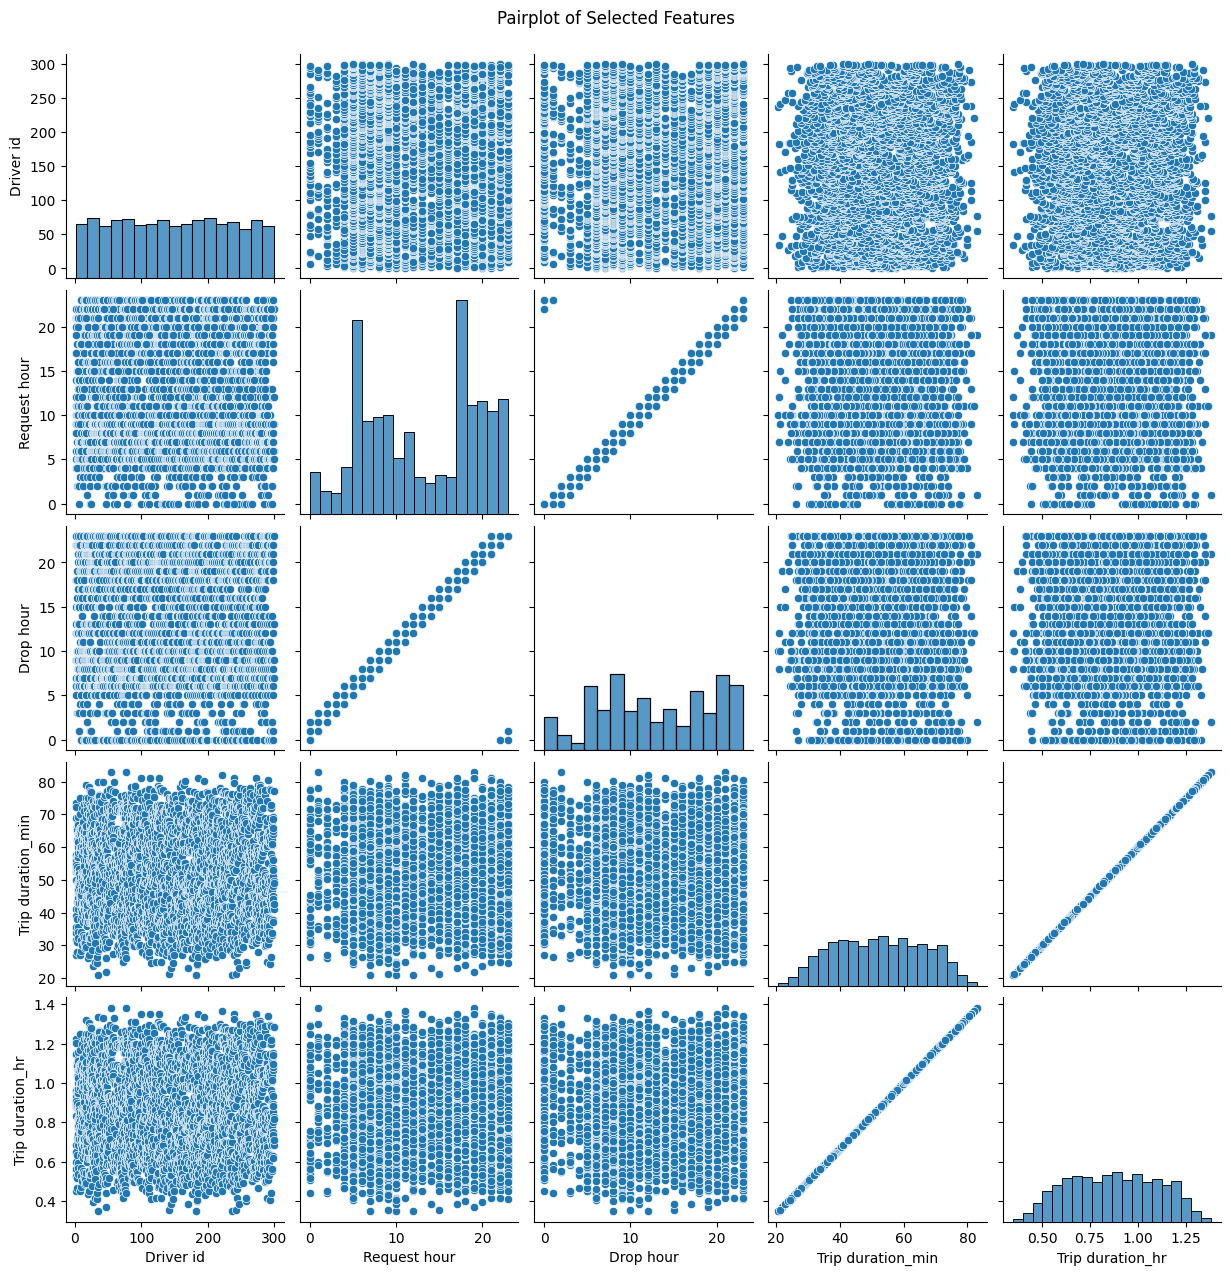

In [66]:
# Pairplot
sns.pairplot(df_selected)
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

What is/are the insight(s) found from the chart?

1. Perfect Linear Relationship
- **Between**: `Trip duration_min` and `Trip duration_hr`
- **Insight**: Drop one of these columns to avoid redundancy.

2. Strong Linear Pattern Between Request Hour and Drop Hour
- **Observation**: Clear diagonal line suggests most trips start and end in nearby hours.
- **Insight**: Useful for predicting drop time from request time and identifying peak periods.
3. Uniform Distribution of Drivers
- **Observation**: `Driver ID` appears to be uniformly spread.
- **Insight**: No driver bias, good for fair load balancing.
4. Skewed Request and Drop Hours
- **Observation**: Histograms show higher requests and drops in specific hours (e.g., morning and evening peaks).
- **Insight**: Useful for demand forecasting and scheduling.
5. Trip Duration Histogram
- **Observation**: Duration appears symmetric and normally distributed.
- **Insight**: Duration is consistent and predictable, aiding in time estimations and SLA planning
6. No Obvious Clusters or Anomalies
- **Observation**: Scatter plots do not show distinct clusters or outliers.
- **Insight**: Data is continuous and smooth — suitable for regression or simple ML models without complex preprocessing.
---
*Operational Implications*
- Simplify the model by removing one of the duration features.

- Optimize driver schedules based on peak request/drop hours.

- Fair driver assignment can be maintained due to uniform distribution.

- Use hour features for peak period pricing or demand heatmaps.

## **Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Align Supply with Peak Demand Hours:

 - Early morning (City) and Evening (Airport) show severe gaps between demand and supply.

 * Recommendation: Introduce dynamic fleet allocation — assign more drivers during these high-demand times to reduce lost trips.

2. Shift Planning & Incentive Schemes:

 - Encourage drivers to work during underserved periods (e.g., 5–9 AM in the city, 5–9 PM at the airport).

 - Recommendation: Use monetary incentives, bonuses, or priority access to trips during these peak hours.

3. Improve Real-Time Monitoring and Alerts:

 - The demand-supply gap fluctuates hour-by-hour.

 - Recommendation: Implement a real-time demand forecasting dashboard to alert operations teams and guide driver deployments.

4. Introduce Location-Specific Strategies:

 - Patterns differ between city and airport areas (e.g., city has early morning gaps, airport has evening gaps).

 - Recommendation: Customize strategies for each pickup zone instead of applying a uniform approach.

5. Optimize Idle Fleet & Reduce Wastage:

 - Times like late night and afternoon show relatively lower demand.

 - Recommendation: Avoid over-supplying during these periods — reallocate or limit fleet deployment to save costs.

# **Conclusion**

- The analysis reveals a significant mismatch between demand and supply at specific hours and locations — particularly early mornings in the city and evenings at the airport. These gaps result in missed trip opportunities and dissatisfied customers.

- To address this, Uber should:

 1. Reallocate drivers strategically during high-demand time slots.

 2. Offer time-based and location-based incentives to drivers.

 3. Leverage real-time data monitoring to dynamically respond to demand surges.

 4. Customize strategies for city and airport zones individually.

- By implementing these data-driven strategies, Uber can enhance operational efficiency, increase trip fulfillment, and boost customer satisfaction, ultimately helping to achieve its business objective.